# Exercício Senso 2022

## Conhecendo o Brasil

#### Conhecer em detalhe como é e como vive o nosso povo é de extrema importância para o governo e para a sociedade. Os resultados obtidos através da realização do Censo Demográfico permitem traçar um retrato abrangente e fiel do País.

#### O Censo Demográfico produz informações atualizadas e precisas, que são fundamentais para o desenvolvimento e implementação de políticas públicas e para a realização de investimentos, tanto do governo quanto da iniciativa privada. Além disso, uma sociedade que conhece a si mesma pode executar, com eficácia, ações imediatas e planejar com segurança o seu futuro.

#### Retratar o Brasil que está entrando numa nova década é um desafio para o IBGE. Qual é o tamanho da população brasileira? Em que condições vive? Como se distribui no Território Nacional? Qual é o nível de escolaridade de nossas crianças e jovens? Quais as condições de emprego e renda da população? Estas e muitas outras perguntas serão respondidas pelo Censo Demográfico que o IBGE realiza em 2022.

[IBGE](https://censo2022.ibge.gov.br/sobre/conhecendo-o-brasil.html)

In [37]:
#bibliotecas
!pip install geopandas
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json

## Crescimento Populacional

#### Baseado no dataset **Censo2022_CrescimentoPopulacionalBrasil.csv**, crie um gráfico de linha semelhante ao encontrado no site do IBGE:

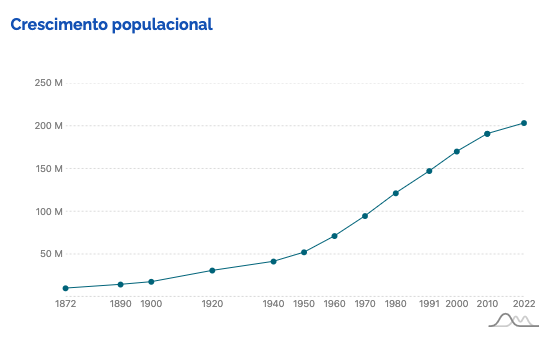


In [3]:
df = pd.read_csv('Censo2022_CrescimentoPopulacionalBrasil.csv', sep=';')
df.head()

,Ano da pesquisa,População(pessoas),Recorte Geográfico,Unnamed: 3,Unnamed: 4
0,1872,9930478,Brasil,NaN,NaN
1,1890,14333915,Brasil,NaN,NaN
2,1900,17438434,Brasil,NaN,NaN
3,1920,30635605,Brasil,NaN,NaN
4,1940,41236315,Brasil,NaN,NaN


In [14]:
fig = px.line(df, x='Ano da pesquisa', y='População(pessoas)', title='Crescimento Populacional', markers=True,)
fig.show()


## Pirâmide Etária

#### Baseado no dataset **Censo2022_PiramideEtariaBrasil.csv**, crie um gráfico de barras semelhante ao encontrado no site do IBGE:

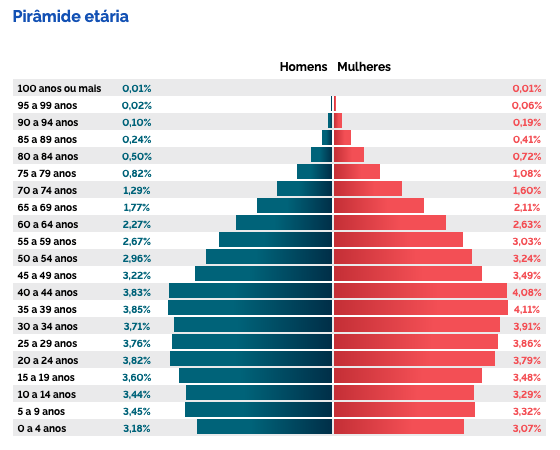

In [103]:
df = pd.read_csv('/content/Censo2022_PiramideEtariaBrasil.csv', sep=';')
df

,Grupo de idade,População feminina(pessoas),População masculina(pessoas),Recorte Geográfico,Unnamed: 4,Unnamed: 5
0,100 anos ou mais,27244,10570,Total,Brasil,NaN
1,95 a 99 anos,114859,50319,Total,Brasil,NaN
2,90 a 94 anos,385388,194341,Total,Brasil,NaN
3,85 a 89 anos,835554,493649,Total,Brasil,NaN
4,80 a 84 anos,1465178,1009852,Total,Brasil,NaN
5,75 a 79 anos,2189593,1657786,Total,Brasil,NaN
6,70 a 74 anos,3243186,2615350,Total,Brasil,NaN
7,65 a 69 anos,4288180,3588052,Total,Brasil,NaN
8,60 a 64 anos,5338555,4605834,Total,Brasil,NaN
9,55 a 59 anos,6149601,5419505,Total,Brasil,NaN


In [ ]:
#grafico em barras modo piramide

fig = px.bar(df, x="Faixa Etária", y=["0 a 4 anos", "5 a 9 anos", "10 a 14 anos

## População por Unidade da Federação

#### Baseado no dataset **Censo2022_NivelInstrucaoBrasil.csv**, crie um gráfico de waffle semelhante ao encontrado no site do IBGE:

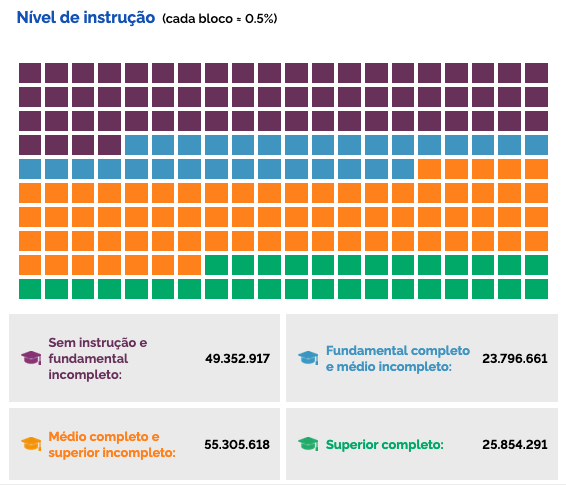

In [22]:
df3 = pd.read_csv('Censo2022_NivelInstrucaoBrasil.csv', sep=';')
df3.head()

,Nível de instrução,População (pessoas),Recorte Geográfico,Unnamed: 3,Unnamed: 4
0,Sem instrução e fundamental incompleto,49352917,Brasil,NaN,NaN
1,Fundamental completo e médio incompleto,23796661,Brasil,NaN,NaN
2,Médio completo e superior incompleto,55305618,Brasil,NaN,NaN
3,Superior completo,25854291,Brasil,NaN,NaN


Output hidden; open in https://colab.research.google.com to view.

## População por Unidade da Federação

#### Baseado no dataset **Censo2022_PopulacaoUF.csv.csv**, crie um mapa coroplético semelhante ao encontrado no site do IBGE:
*Utilize os dados de coordenadas do arquivo brasil_estados.json

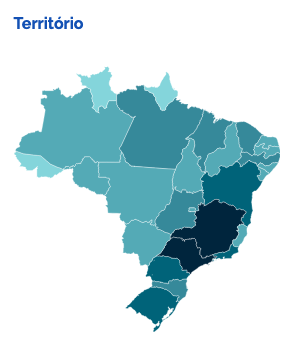

In [158]:
# 1) Carrega população
df_pop = pd.read_csv('Censo2022_PopulacaoUF.csv', sep=';')
df_pop

,Unidades da federação,pessoas
0,Acre,830018
1,Alagoas,3127683
2,Amapá,733759
3,Amazonas,3941613
4,Bahia,14141626
5,Ceará,8794957
6,Distrito Federal,2817381
7,Espírito Santo,3833712
8,Goiás,7056495
9,Maranhão,6776699


In [159]:
# 2) Carrega GeoJSON como GeoDataFrame
gdf = gpd.read_file('/content/brasil_estados.json')
gdf

Output hidden; open in https://colab.research.google.com to view.

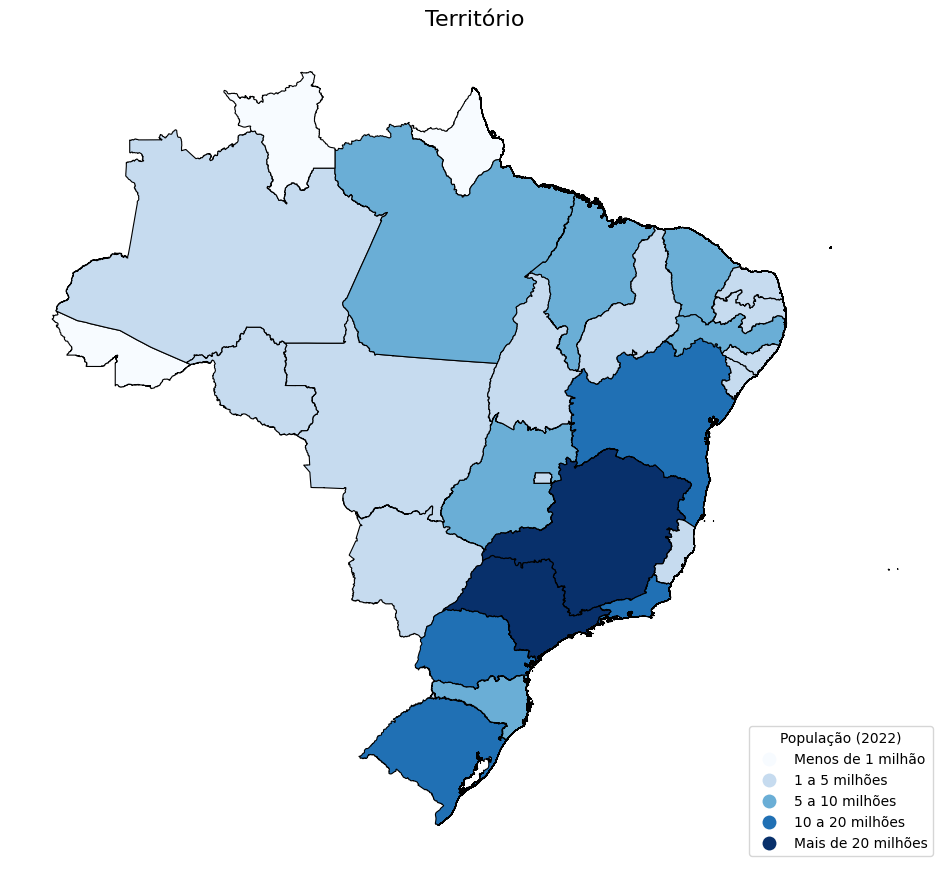

In [162]:
#    Ajusta nomes para dar merge
#    Depende de como seu GeoJSON chama a coluna de nome do estado.
#    Vou supor que gdf tem uma coluna 'nome' ou 'NM_ESTADO'.
#    Caso seja diferente, use gdf.columns para descobrir.
gdf = gdf.rename(columns={'name':'Unidades da federação'})

#   Faz merge para juntar população
gdf = gdf.merge(df_pop, on='Unidades da federação')

# Define os intervalos de população
# Movendo esta linha para *depois* do merge
bins = [0, 1_000_000, 5_000_000, 10_000_000, 20_000_000, gdf['pessoas'].max() + 1]

# Define os rótulos personalizados
labels = [
    'Menos de 1 milhão',
    '1 a 5 milhões',
    '5 a 10 milhões',
    '10 a 20 milhões',
    'Mais de 20 milhões'
]

# Cria uma nova coluna categórica no GeoDataFrame
gdf['faixa_pop'] = pd.cut(gdf['pessoas'], bins=bins, labels=labels, include_lowest=True)

#   Plota com coloração por população
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
gdf.plot(
    column='faixa_pop',           # coluna de dados
    cmap='Blues',                # mapa de cores
    linewidth=0.8,               # borda dos estados
    edgecolor='black',
    legend=True,                 # mostra a legenda
    legend_kwds={'title': "População (2022)", 'loc': 'lower right'},
    ax=ax
)

ax.set_title('Território', fontsize=16)
ax.axis('off')  # desliga eixos

plt.show()